## Synthetic User Population Visualization

Generate a synthetic population of latent trait vectors with `generate_user_population()`, inspect it as a DataFrame, and visualize the two-dimensional latent space.


### Generate Users


In [6]:
n_users = 100
dim = 2
target_mean = np.array([0.0, 0.0])
#target_covariance = np.array([[1.0, 0.45],[0.45, 1.25],])
target_covariance = 25*np.eye(2)	

theta = generate_user_population(
    n_users=n_users,
    dim=dim,
    mean=target_mean,
    covariance=target_covariance,
    rng_seed=42,
)

user_df = pd.DataFrame(theta, columns=["theta_1", "theta_2"])
user_df.insert(0, "user_id", [f"user_{i:03d}" for i in range(n_users)])

user_df.head()


,user_id,theta_1,theta_2
0,user_000,1.523585,-5.199921
1,user_001,3.752256,4.702824
2,user_002,-9.755176,-6.510898
3,user_003,0.639202,-1.581213
4,user_004,-0.084006,-4.265220


### Latent Trait Scatter


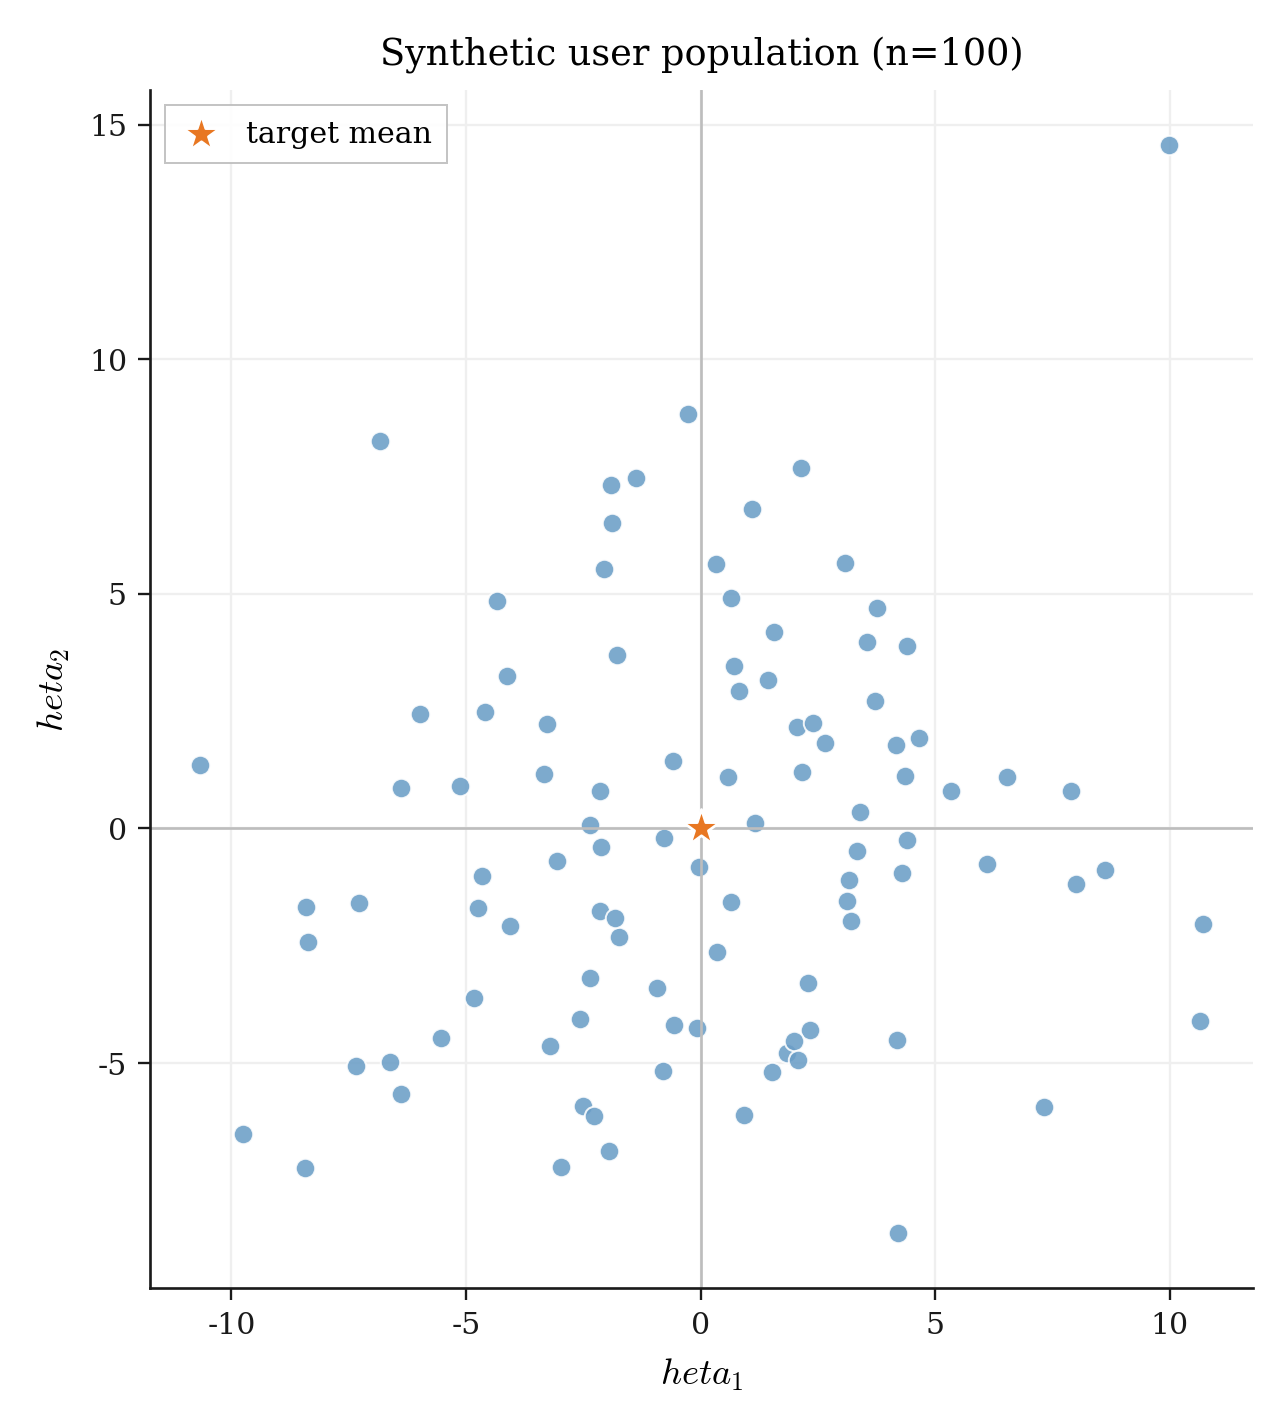

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6.0))

ax.scatter(
    user_df["theta_1"],
    user_df["theta_2"],
    s=34,
    color=PALETTE["blue"],
    edgecolor="white",
    linewidth=0.6,
    alpha=0.88,
)
ax.scatter(
    target_mean[0],
    target_mean[1],
    s=130,
    color=PALETTE["amber"],
    marker="*",
    edgecolor="white",
    linewidth=0.8,
    label="target mean",
    zorder=4,
)

ax.axhline(0, color=PALETTE["rule"], linewidth=0.8)
ax.axvline(0, color=PALETTE["rule"], linewidth=0.8)
ax.set_xlabel(r"$	heta_1$")
ax.set_ylabel(r"$	heta_2$")
ax.set_title(f"Synthetic user population (n={n_users})")
ax.set_aspect("equal", adjustable="box")
style_ax(ax, grid_axis="both")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


### Marginals and Summary Checks


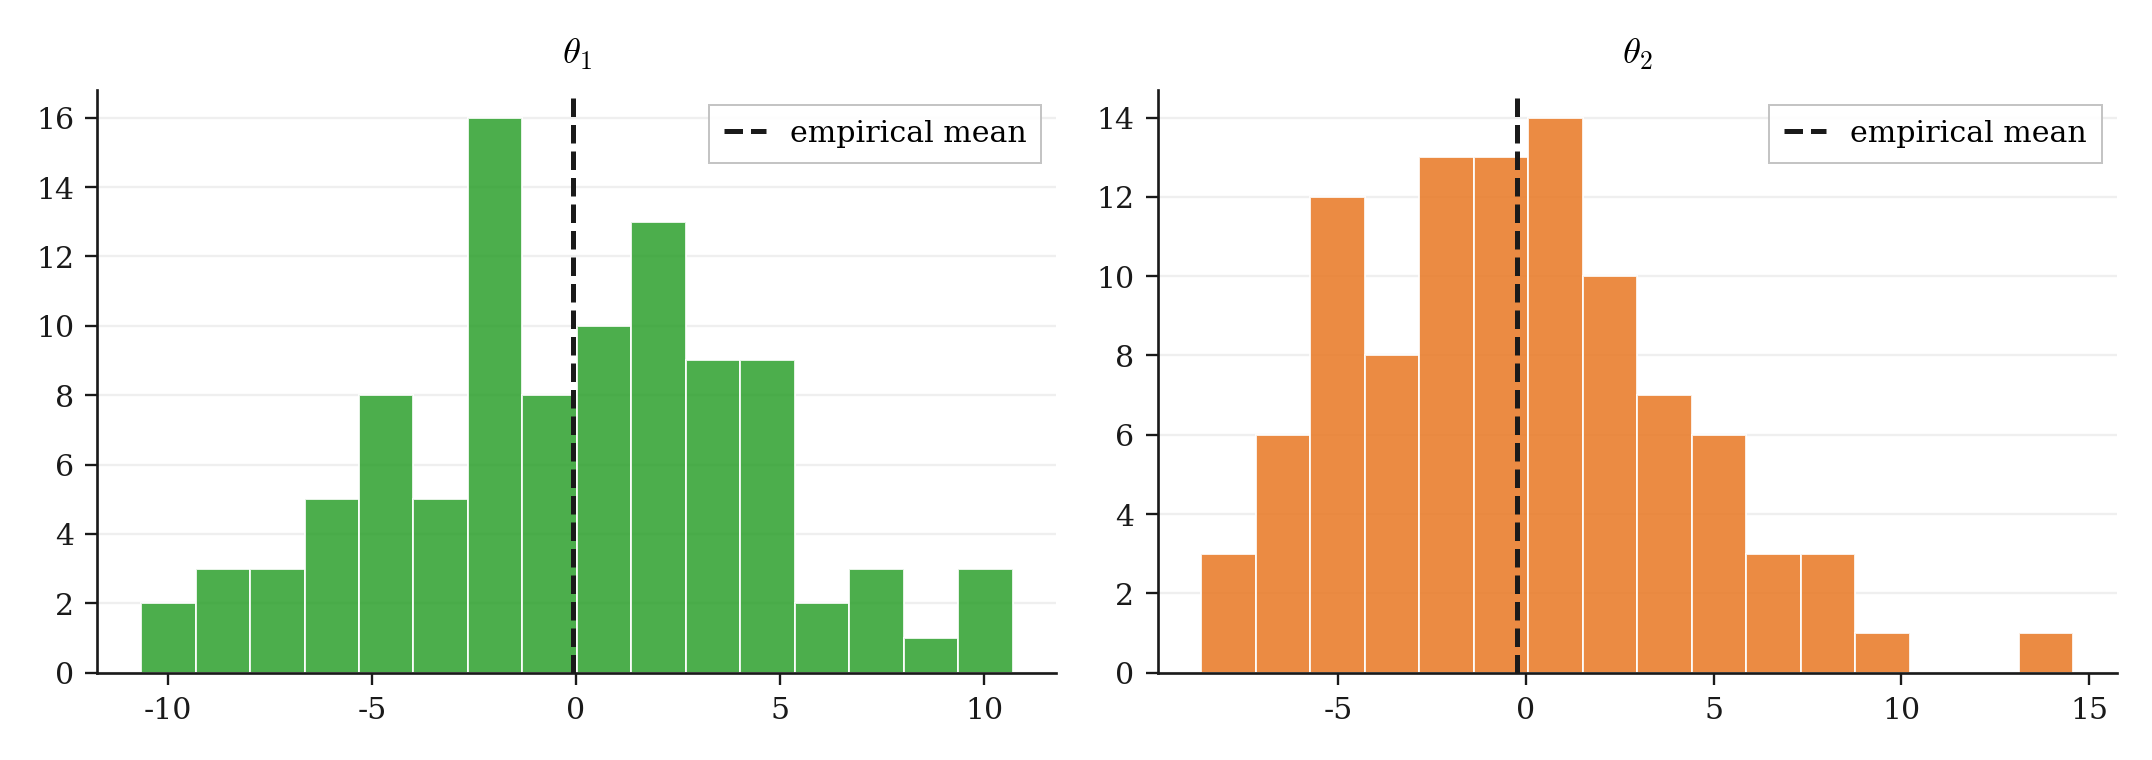

Target mean:
[0. 0.]

Empirical mean:
[-0.074 -0.231]

Target covariance:
[[25.  0.]
 [ 0. 25.]]

Empirical covariance:
[[20.815  3.068]
 [ 3.068 18.259]]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

for ax, column, color in zip(axes, ["theta_1", "theta_2"], [PALETTE["teal"], PALETTE["amber"]]):
    ax.hist(user_df[column], bins=16, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(user_df[column].mean(), color=PALETTE["ink"], linewidth=1.5, linestyle="--", label="empirical mean")
    ax.set_title(rf"$\{column}$")
    style_ax(ax, grid_axis="y")
    ax.legend(frameon=True)

plt.tight_layout()
plt.show()

empirical_mean = user_df[["theta_1", "theta_2"]].mean().to_numpy()
empirical_covariance = user_df[["theta_1", "theta_2"]].cov().to_numpy()

print("Target mean:")
print(target_mean)
print("\nEmpirical mean:")
print(np.round(empirical_mean, 3))
print("\nTarget covariance:")
print(target_covariance)
print("\nEmpirical covariance:")
print(np.round(empirical_covariance, 3))


### One User Wrapper


In [9]:
theta_true = sample_theta_true(
    dim=2,
    mean=target_mean,
    covariance=target_covariance,
    rng_seed=7,
)

theta_true


array([0.00615077, 1.49372769])